In [1]:
# Experiment
# - Info-Gain SoRL
# - 2 Phase switch, Phase I: baseline language modeling, Phase II: SoRL with info-gain target & reward scaling.

import torch
from sorl.gat_sim import GAT, GATConfig, BOS_TOKEN_ID
torch.set_float32_matmul_precision('high')  # Enable TF32 for ~2x speedup
# For fast training, set 'BOS_TOKEN_ID' to 15 in 'sorl/gat_sim.py' 

gat_config = GATConfig(
    vocab_sizes=[BOS_TOKEN_ID+1, 16],  # 16 abstract tokens
    n_layer=4,
    n_head=4,
    n_embd=128,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

model = GAT(gat_config)
# model = model.to("cuda")
# model = torch.compile(model)

# 1. load a small subset of the dataset (checked)
# 2. tokenize & build data loader (checked)
# 3. train with SoRL. 
# 4. visualize abstraciton dynamics (similar to copy-n-paste, but more generally on per-n-gram statistics)

In [2]:
from data.tinystory_local import TinyStoriesDataLoader, collect_rollout_statistics, AbstractionStatistics
from data.tinystory_local import visualize_dynamics
import tiktoken 

# TinyStories Dataset + GPT2 tokenizer
# -------------------------------------
num_stories = 100
max_len = 36
K = 4
loader = TinyStoriesDataLoader(num_stories=num_stories, max_len=max_len, chunk_size=K, device='cpu')

doc_len = max_len  + (max_len - 1) // K # <-- doc len contains abstract tokens
batch_size = 8
memory_span = 2 * max_len + 2
attn_blocksize = 1792
max_iterations = 2

# ---- stat collection ---
abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# --- tokenizer --- 
enc = tiktoken.get_encoding("gpt2")
eot = enc._special_tokens['<|endoftext|>']

Loading 100 stories from TinyStories train...
Loaded 100 stories, 3600 tokens total, 0.01 MB
Collected 726 unique 4-chunks


In [ ]:
# train SoRL with interleaved phase switch (phase I: baseline lm | phase II: SoRL with info-gain target & reward scaling)
from sorl.neo_utils import sorl_evaluate_v2, sorl_search_v7
from sorl.topo import orthogonalize_abs_param
from collections import defaultdict
from sorl.info import SoRLLoss_v6 
from sorl.forget import compute_abs_stats

# --- orthogonal initialization on abs param --- 
# orthogonalize_abs_param(model, do_wte=True, do_head=True)

loss_fn = SoRLLoss_v6(model.vocab_sizes[1], decay=0.8, target_vocab_util=0.9)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.1)
n = 2
temperature = torch.tensor([0.0, 5.0], device=model.device)
num_steps = 1200
alpha_abs = 0.1
alpha_soft_zipf = 1.0
alpha_topo = 0.0

record = defaultdict(list)
img_frames = []

for step in range(num_steps): 

    optimizer.zero_grad()

    tokens, doc_ids = loader.get_batch(batch_size)

    with torch.no_grad(): 
        best_data, info_gain_reward, base_traj_ppt = sorl_search_v7(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature, truncate_seq_len=False)

    # --- compute loss --- 
    base_traj_loss = model.forward(tokens, memory_span, attn_blocksize)[0].mean()
    info_loss, abs_loss, zipf_bigram_loss, topo_loss = loss_fn(best_data, model, base_traj_ppt.detach(), memory_span, attn_blocksize, info_gain_reward)    
    loss = base_traj_loss + info_loss + alpha_abs * abs_loss + alpha_soft_zipf * zipf_bigram_loss

    # --- optimize --- 
    loss.backward() 
    optimizer.step()

    # ---- search info gain ---
    rel_info_gain = ((-info_loss) / base_traj_loss).item()

    if step % 2 == 0: 
        with torch.no_grad(): 
            temperatures_eval = torch.tensor([0.0, 10.0], device=model.device)

            traj_loss, abs_logits, abs_tokens, doc_rel_info_gain, rel_info_gain, greedy_adv, base_traj_loss = compute_abs_stats(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperatures_eval,
                                                                                        truncate_seq_len=False)
            abs_stats.update(abs_logits, traj_loss, doc_rel_info_gain, abs_tokens, doc_ids)

            record['vocab_util'].append(abs_stats.vocab_util * 100)
            record['greedy_adv'].append(greedy_adv.item() * 100)
            record['traj_loss'].append(traj_loss.mean().item())
            record['base_traj_loss'].append(base_traj_loss.item())
            record['bigram_rep_rate'].append(abs_stats.bigram_rep_rate)
            record['rel_search_info_gain'].append(rel_info_gain)

        print(f"\nstep {step} | base traj loss: {base_traj_ppt.mean().item():.2f} | cond traj loss: {traj_loss.mean().item():.2f} | rel search info gain: {rel_info_gain * 100:.2f}% | greedy adv: {greedy_adv.item() * 100:.2f}% | vocab util: {abs_stats.vocab_util * 100:.2f}%  | bigram-zipf kl: {zipf_bigram_loss.item():.2f} | topo similarity: {-topo_loss.item():.2f} | bigram rep rate: {abs_stats.bigram_rep_rate:.2f} | rel info gain (search): {rel_info_gain:.2f}")
        
        img = visualize_dynamics(abs_stats, loader, model, enc, K, step)
        img_frames.append(img)
        # break


step 0 | base traj loss: 10.26 | cond traj loss: 8.33 | rel search info gain: -0.09% | greedy adv: 0.07% | vocab util: 87.50%  | bigram-zipf kl: 79.04 | topo similarity: 0.93 | bigram rep rate: 0.92 | rel info gain (search): -0.00

step 2 | base traj loss: 10.14 | cond traj loss: 8.21 | rel search info gain: -0.24% | greedy adv: 0.04% | vocab util: 87.50%  | bigram-zipf kl: 50.36 | topo similarity: 0.94 | bigram rep rate: 0.87 | rel info gain (search): -0.00

step 4 | base traj loss: 9.93 | cond traj loss: 7.98 | rel search info gain: -0.18% | greedy adv: -0.01% | vocab util: 87.50%  | bigram-zipf kl: 32.54 | topo similarity: 0.79 | bigram rep rate: 0.81 | rel info gain (search): -0.00

step 6 | base traj loss: 9.55 | cond traj loss: 7.65 | rel search info gain: -0.15% | greedy adv: 0.00% | vocab util: 87.50%  | bigram-zipf kl: 21.25 | topo similarity: 0.81 | bigram rep rate: 0.80 | rel info gain (search): -0.00

step 8 | base traj loss: 9.18 | cond traj loss: 7.34 | rel search info g

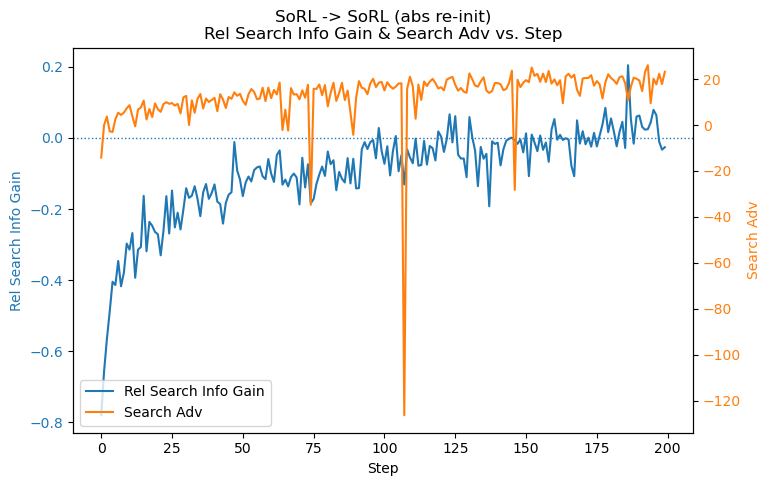

In [ ]:
from sorl.forget import plot_rel_info_gain_vs_step

plot_rel_info_gain_vs_step(record)

In [ ]:
# exp 1. I use one forward propagation to compute base traj ppt & base traj loss
# -> but this produces a differetn training mechanism, where base traj loss lags behind
# --- base traj loss: 3.20 | cond traj loss: 1.43 | rel search info gain: >50%

# exp 2. 
# .forward to compute 'base_traj_ppt' within sorl search, and re-compute it after it to obtain 'base_traj_los'
# whilst it should theoretically be the same, it produces different training dynamics (why?)
# we observe negative search info gain, better traj loss than cond traj loss, and increasing greedy adv
# --- base traj loss: 1.11 | cond traj loss: 1.19 | rel search info gain: -1.8%

# exp 2. 
# continuously train on ckpt from exp 2, but re-initilalize wte & lm_head for abstrct tokens
# rel info gain raise up from -78% to ~0% (in some case positive)
# (obs) towards later half of this runs, we starts to observe positive rel search info gain, with seemingly more positive values as training proceeds.
# - visualization: indicates a monotonic trend of increasing rel search info gain in this runs. 

# exp 3. 
# continuously train on ckpt from exp 2, no re-initialization
# rel info gain "oscillates" with avg value of ~1.5%

In [10]:
from sorl.forget import compute_abs_stats

n = 1
temperature = torch.tensor([0.0] + [5.0] * (n - 1))

# ---- statistics on info gain reward ---
i = 0
batch_size = 16
ig = []
while i < len(loader.stories): 
    batch_indices = torch.arange(i, min(i + batch_size, len(loader.stories)))
    loader.get_specific(batch_indices) 
    i += batch_size
    tokens, doc_ids = loader.get_specific(batch_indices) 
    traj_loss, abs_logits, abs_tokens, doc_rel_info_gain, rel_info_gain = compute_abs_stats(tokens, model, n=n, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=attn_blocksize, temperature=temperature,
                                                                                        truncate_seq_len=False)
    abs_stats.update(abs_logits, traj_loss, doc_rel_info_gain, abs_tokens, doc_ids)
    # ig.append(rel_info_gain)
    # break

In [ ]:
# rel_info_gain
torch.tensor(ig).mean()

# (Scaling test-time compute in abstract space --> "thinking is acting in an imaginary space")
# n=1, t=[0] -> relative info gain: 0.59% 
# n=2, t=[0, 5] -> relative info gain: 3.6% 
# n=5, t=[0, 5, ..., 5] -> relative info gain: 6.08%
# n=8, t=[0, 5, ..., 5] -> relative info gain: 4.8%
# n=10, t=[0, 5, ..., 5] -> relative info gain: 7.26%
# n=20, t=[0, 5, ..., 5] -> relative info gain: 6.7% 
# n=30, t=[0, 5, ..., 5] -> relative info gain: 7.55%



tensor(0.0059)

<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/var/folders/vx/6bqm9pg11yl1j_t5rgg9zczm0000gn/T/ipykernel_6243/2572211333.py:16: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x_fit, y_fit, '--', color='gray', alpha=0.5, label=f'Log Trend ($y={coeffs[0]:.2f} \ln(x) + {coeffs[1]:.2f}$)')


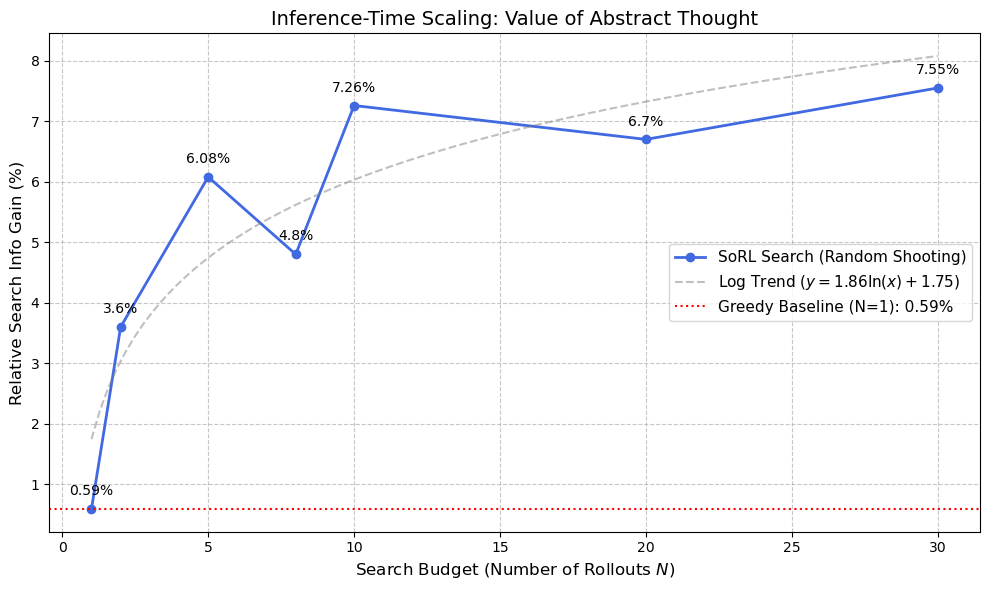

In [142]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your experiment
n_values = [1, 2, 5, 8, 10, 20, 30]
rel_info_gain = [0.59, 3.6, 6.08, 4.8, 7.26, 6.7, 7.55]

plt.figure(figsize=(10, 6))
plt.plot(n_values, rel_info_gain, 'o-', linewidth=2, color='royalblue', label='SoRL Search (Random Shooting)')

# Add a smooth trendline (Logarithmic fit: y = a * ln(x) + b)
# Filter out N=1 for fit to avoid log(1)=0 singularity issues or just fit all
x_fit = np.linspace(1, 30, 100)
coeffs = np.polyfit(np.log(n_values), rel_info_gain, 1)
y_fit = coeffs[0] * np.log(x_fit) + coeffs[1]
plt.plot(x_fit, y_fit, '--', color='gray', alpha=0.5, label=f'Log Trend ($y={coeffs[0]:.2f} \ln(x) + {coeffs[1]:.2f}$)')

# Formatting
plt.axhline(y=rel_info_gain[0], color='r', linestyle=':', label=f'Greedy Baseline (N=1): {rel_info_gain[0]}%')
plt.xlabel('Search Budget (Number of Rollouts $N$)', fontsize=12)
plt.ylabel('Relative Search Info Gain (%)', fontsize=12)
plt.title('Inference-Time Scaling: Value of Abstract Thought', fontsize=14)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)

# Annotate points
for i, txt in enumerate(rel_info_gain):
    plt.annotate(f"{txt}%", (n_values[i], rel_info_gain[i]), 
                 textcoords="offset points", xytext=(0,10), ha='center')

plt.tight_layout()
plt.show()

In [107]:
# temperature
n = 10 
temperature = torch.tensor([0.0] + [5.0] * (n - 1))

In [114]:
search_data, search_ppt, abs_logits = sorl_rollout_v3(tokens, model, n=n, K=K, 
                                                            max_iterations=max_iterations,
                                                            memory_span=memory_span,
                                                            attn_blocksize=attn_blocksize,
                                                            temperature=temperature,
                                                            truncate_seq_len=False)
search_ppt = search_ppt.reshape(search_data.shape[0], -1)

# Get valid positions
bos_pos_mask = torch.logical_and(
    search_data[:, :-1] != BOS_TOKEN_ID, 
    search_data[:, 1:] != BOS_TOKEN_ID
).float()

traj_mask = (search_data[:, 1:] < model.vocab_sizes[0]).float()

# --- greedy rollout's advantage ---
valid_traj_mask = bos_pos_mask * traj_mask
raw_ppt_adv = (search_ppt[1:].mean(dim=0) - search_ppt[0]) / (search_ppt[1:].mean(dim=0) + 1e-8)
search_adv = (raw_ppt_adv * valid_traj_mask[0]).sum() / valid_traj_mask[0].sum().clamp(min=1)

# --- losses ---
greedy_ppt = search_ppt[0]
abs_mask = 1 - traj_mask[0]

valid_traj = valid_traj_mask[0]
traj_ppt = search_ppt[0] * valid_traj
doc_idx = (search_data == BOS_TOKEN_ID).cumsum(dim=1)
doc_idx = doc_idx - doc_idx.min(dim=1, keepdim=True).values # idx starts from 0  
doc_ppt = avg_ppt_per_sample(traj_ppt.unsqueeze(0), doc_idx[:1, 1:]).squeeze(0)

greedy_abs_logits = abs_logits[0, abs_mask.bool(), :]
greedy_abs_tokens = search_data[0, 1:][abs_mask.bool()]

base_traj_ppt, _  = model.forward(tokens, memory_span, attn_blocksize)
levels = (search_data >= model.vocab_sizes[0]).long()
best_data, best_ppt, _, info_gain_reward = select_best_info_gain(tokens, base_traj_ppt, search_data, search_ppt, levels)

traj_mask = best_data[0, 1:] < model.vocab_sizes[0]
best_traj_ppt = best_ppt[traj_mask]
info_gain = (base_traj_ppt[..., :best_traj_ppt.shape[-1]] - best_traj_ppt) # traj ppt might be truncated

rel_info_gain = info_gain.mean() / base_traj_ppt[..., :best_traj_ppt.shape[-1]].mean() # focus on hard case

rel_info_gain_v2 = (info_gain / base_traj_ppt[..., :best_traj_ppt.shape[-1]].clamp(min=1e-8)).mean() # focus on simple case

traj_mask = best_data[0, 1:] < model.vocab_sizes[0]
traj_doc_idx = doc_idx[0, 1:][traj_mask]
doc_info_gain = avg_ppt_per_sample(info_gain.unsqueeze(0), traj_doc_idx.unsqueeze(0)).squeeze(0)
doc_base_traj_ppt = avg_ppt_per_sample(base_traj_ppt.unsqueeze(0), traj_doc_idx.unsqueeze(0)).squeeze(0)
doc_rel_info_gain = doc_info_gain / doc_base_traj_ppt


In [113]:
traj_mask = best_data[0, 1:] < model.vocab_sizes[0]


In [110]:
doc_rel_info_gain, rel_info_gain

(tensor([ 0.0329,  0.8196, -0.0504, -0.2552], grad_fn=<DivBackward0>),
 tensor(0.2476, grad_fn=<DivBackward0>))

In [ ]:
info_gain_reward

tensor([1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376,
        1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376,
        1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376,
        1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376,
        1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0376, 1.0371, 1.0371,
        1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371,
        1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371,
        1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371,
        1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371,
        1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0371, 1.0234, 1.0234, 1.0234,
        1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234,
        1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234, 1.0234,
        1.0234, 1.0234, 1.0234, 1.0234, 

In [ ]:
# Hypothesis #1. 
# - if SoRL does have a 'schema effect', then the more organized it gets (later ckpt) will have 
#   (1). better learning efficiency
#                            (for this, we might need to use some 'new' stories data point)
#   (2). lesser interference (% of closeness->interference correlation should be lesser) 
#                            (% of closeness->alignment correlation should be higher)

# Question #1. 
# Does SoRL has advantage over baseline in info gain and continual learning? 

# Question #2. 
# Policy lag leads to "search adv" & "greedy adv" gap. resolving this and we'll get a better policy model
# together with a better "greedy adv", the ability to manipulate the inner-monologue can be improved. 

# Question #3. 
# Can we replicate the improvement on big-scale dataset?

# Obs #1. 



In [ ]:


# exp 7. base traj loss included SoRL (with online info gain loss & reward scaling)
# (1). base traj loss and cond traj loss improve simultaneously
# ---- base traj loss: 1.01 | cond traj loss: 1.08 | greedy adv: 18.9% | vocab util: 81.25%
# (2). something about the ability to push both p(s) and p(s | a) up is attractive to me
# Obs #1. During training, the searched abstraction has information gain p(s | a) > p(s)
#         but such advantage doesn't exist in greedy policy rollouts p(s | a*) < p(s)
# Hyp #1. If we train till saturation, we should observe p(s | a*) > p(s)?


# exp 8. base traj loss included SoRL (with online info gain loss & reward scaling), 3x compute
# ---- base traj loss: 0.18 | cond traj loss: 0.19 | greedy adv: 18% | vocab util: 81%
# ---- rel info gain (search): 15.4% (t1=0, t2=5.0)



# Obs #1. We should however note that exp 3 & exp 4 has matching performance. 
#         One prev issue is that SoRL doesn't match baseline in p(s) in TinyStories dataset. 

# Issue #1. How do we avoid the degradation on greedy adv? 

# Idea #1. 
# -> instead of interleaving, how about we combine loss function? 


# base_traj_loss = model.forward(tokens, memory_span, attn_blocksize)[0].mean()
# traj_loss, abs_loss, zipf_bigram_loss, topo_loss = loss_fn(best_data, model, base_traj_ppt, memory_span, attn_blocksize, info_gain_reward)
# some sort of weighted sum of 2 terms ... (we want to encourage info gain & better base traj)



In [44]:
from sorl.forget import collect_forget_data, plot_normalized_correlation_lines, train_forget_vec
from tqdm import tqdm as tqdm

# ---- Memory Interference Experiment ---

# --- Load model, prepare abs stats record ---
model.load_state_dict(torch.load('sorl_tinystories.pt'))

abs_stats = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

abs_stats_post = AbstractionStatistics(
    n_doc=num_stories,
    n_abs=doc_len - max_len,
    abs_vocab_size=model.vocab_sizes[1],
    device=model.device
)

# # ---- Compute 'Forget Matrix' --- 
# forget_mat = torch.zeros(num_stories, num_stories, device=model.device)
# num_steps = 40
# for train_idx in tqdm(range(num_stories)): 
#     forget_vec = train_fogret_vec(train_idx, loader, model, abs_stats, abs_stats_post, optimizer, num_steps,
#                                 max_iterations, memory_span, attn_blocksize, temperature, K, r_min, reward_mode, loss_fn, alpha_abs, alpha_soft_zipf, alpha_topo,
#                                 ckpt_path="sorl_tinystories.pt")
#     forget_mat[train_idx] = forget_vec 

# torch.save(forget_mat, "forget_mat.pt") # save it just in case

# # ---- Visualize 'Forget Matrix' --- 
# correlation_data, ham_corrs = collect_forget_data(forget_mat, abs_stats)

# plot_normalized_correlation_lines(
#     correlation_data, 
#     ham_corrs,
#     xlabel="Abstraction Edit Distance", 
#     ylabel="Forgetting (Δ Perplexity)",
#     title="Distant Abstractions → Less Forgetting (TinyStories)"
# )

In [ ]:
# Exp #1. 
# 'self-organization' of abstraction representation --> will SoRL tries to pull mixing memory apart? 
# Exp #2. 
# setting up tiny memory dataset training pipeline 
# Question #1. 
# What if we use all-rollout SoRL with utility advantage + KL reg terms? 


In [ ]:
from data.tinystory_local import *
from sklearn.decomposition import PCA

cs_sim = abs_stats.compute_cross_doc_logit_sim()
# cs_sim = abs_stats.compute_cross_doc_hamming()
pca = PCA(n_components=2, random_state=42)
coords_2d = pca.fit_transform(cs_sim.cpu().numpy())

# Now use in 3D visualization
train_idx = 0
perplexity = forget_mat[train_idx]
img = visualize_forget_terrain(coords_2d, perplexity, trained_idx=train_idx, step=step)
# img = visualize_perplexity_terrain(coords_2d, perplexity, trained_idx=train_idx, step=step)

In [4]:
# Hypothesis #2. 
# ------------------------------------------------------------
# forget(i | j) is proportional to 1 / d(a_i, a_j)
# dis-similar concept is less likely to be overwritten by each other
# similar concept is more likely to be overwritten by each other
# the emerged abstraction system from SoRL can describe such similarity via d(a_i, a_j)
# ------------------------------------------------------------

# Experiment 
# (a). Train till emergence
# (b). Train with specific order. 
# (c). Record 'forgetting matrix'

import numpy as np
np.array(record['topo_loss'][:5]).mean(), np.array(record['topo_loss'][-5:]).mean()

(-0.7774280548095703, -0.7865824460983276)

In [7]:
if len(img_frames) > 0:
    img_frames[0].save(
        'tinystories_dynamics (continuous SoRL with base traj loss, online info gain loss & reward scaling.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

Saved GIF with 200 frames


In [ ]:
# Generate with SoRL trained on TinyStories Dataset
# -------------------------------------------------
from sorl.neo_utils import generate
from data.tinystory_local import visualize_interleaved_alignment    

min_temperature = 0.0
tokens, doc_ids = loader.get_batch(1)

idx = tokens[:, :15].clone()

img_frames = []
for i in range(30): 
    idx = generate(model, idx, K=K, max_iterations=max_iterations, memory_span=memory_span, attn_blocksize=1792, temperature=torch.tensor(min_temperature))
    idx_without_abstraction = idx[idx < model.vocab_sizes[0]]
    img = visualize_interleaved_alignment(idx, model, enc, K=K, max_chunks=8)
    img_frames.append(img)

# ---- save to gif ----
if len(img_frames) > 0:
    img_frames[0].save(
        'tiny-tiny-stories-generation.gif',
        save_all=True,
        append_images=img_frames[1:],
        duration=400,  # milliseconds per frame
        loop=0  # 0 = infinite loop
    )
    print(f"Saved GIF with {len(img_frames)} frames")

In [ ]:
# Request #1. 
# -> Full scale experiment on TinyStories & FineWeb

In [ ]:
# marg cond w = 1.0 
# traj_loss: 0.85 | abs_loss: 0.04 | search adv: 21.01% | vocab util: 93.75%  | marg_ent: 2.67 | cond_ent: 0.05 | avg cos sim: 0.44

# soft bigram zipf kl w = 1.0 
# traj_loss: 0.89 | abs_loss: 0.53 | search adv: 25.84% | vocab util: 68.75%  | kl_soft_zipf: 0.24 | avg cos sim: 0.47
# -> visually I observe much less 'repetitions'

# soft bigram zipf kl w = 1.0 & utility reward scaling r = max(p(s|a)/p(s), 1.0)
# traj_loss: 0.79 | abs_loss: 0.40 | search adv: 30.13% | vocab util: 62.50%  | kl_soft_zipf: 0.17 | avg cos sim: 0.44 | topo sim: 0.77 

# soft bigram zip w=1.0 & utility reward scaling & topo reg w=1.0
# traj loss: 1.50 | search adv: 20% | avg cos sim: 0.24 | topo sim: 0.53
# => degrades utility, no go

